In [13]:
import os

print(os.getcwd())


c:\Users\rishi\Customer_Churn_Analysis\Notebooks


In [15]:
import pandas as pd

df = pd.read_csv("../Data/telco.csv")
print(df.head())

  Customer ID  Gender  Age Under 30 Senior Citizen Married Dependents  \
0  8779-QRDMV    Male   78       No            Yes      No         No   
1  7495-OOKFY  Female   74       No            Yes     Yes        Yes   
2  1658-BYGOY    Male   71       No            Yes      No        Yes   
3  4598-XLKNJ  Female   78       No            Yes     Yes        Yes   
4  4846-WHAFZ  Female   80       No            Yes     Yes        Yes   

   Number of Dependents        Country       State  ...  \
0                     0  United States  California  ...   
1                     1  United States  California  ...   
2                     3  United States  California  ...   
3                     1  United States  California  ...   
4                     1  United States  California  ...   

  Total Extra Data Charges  Total Long Distance Charges  Total Revenue  \
0                       20                         0.00          59.65   
1                        0                       390.80   

In [8]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import seaborn as sns
df=pd.read_csv("C:/Users/Ammar Shaikh/OneDrive/Desktop/DATA ANALYST JOURNEY/Customer-Churn-Analysis/data/telco_churn.csv")
df.head()

In [16]:
#============================
#Data Inspection
#============================

#first few rows
print("\n First 5 Rows:")
print(df.head(5))

#last few rows
print("\n last 5 Rows:")
df.tail(5)

#column with data types
print("column with their data types")
print(df.dtypes)

#column information
print("column information")
print(df.info())


 First 5 Rows:
  Customer ID  Gender  Age Under 30 Senior Citizen Married Dependents  \
0  8779-QRDMV    Male   78       No            Yes      No         No   
1  7495-OOKFY  Female   74       No            Yes     Yes        Yes   
2  1658-BYGOY    Male   71       No            Yes      No        Yes   
3  4598-XLKNJ  Female   78       No            Yes     Yes        Yes   
4  4846-WHAFZ  Female   80       No            Yes     Yes        Yes   

   Number of Dependents        Country       State  ...  \
0                     0  United States  California  ...   
1                     1  United States  California  ...   
2                     3  United States  California  ...   
3                     1  United States  California  ...   
4                     1  United States  California  ...   

  Total Extra Data Charges  Total Long Distance Charges  Total Revenue  \
0                       20                         0.00          59.65   
1                        0                

In [17]:
#Handling the missing   values
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [24]:
#duplicates values in columns
print(df.duplicated().sum())

0


In [ ]:
#removing the customer_id column
df.drop("customerID",axis=1,inplace=True)
df.columns

In [ ]:
#conversion of data type of column TotalCharges object to TotalCharges integer
print((df["TotalCharges"] ==" ").sum())
df["TotalCharges"]=df["TotalCharges"].replace(" ",pd.NA)
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"])
df.dropna(inplace=True)
df["TotalCharges"].dtypes
df.dtypes

In [ ]:
#Statistical Summary of every column

#statistical Summary of numerical column
df.describe()

In [ ]:
#Categorical summary of column
categorical_col=df.select_dtypes(include='object').columns
for col in categorical_col[:5]:
    print("\n")
    print(df[col].value_counts().head(5))

In [23]:
#unique values in each column
unique_counts=pd.DataFrame({
    "Column name":df.columns,
    "Unique_counts":[df[col].nunique() for col in df.columns],
    "Column data type":df.dtypes.values
})
print(unique_counts)

                          Column name  Unique_counts Column data type
0                         Customer ID           7043              str
1                              Gender              2              str
2                                 Age             62            int64
3                            Under 30              2              str
4                      Senior Citizen              2              str
5                             Married              2              str
6                          Dependents              2              str
7                Number of Dependents             10            int64
8                             Country              1              str
9                               State              1              str
10                               City           1106              str
11                           Zip Code           1626            int64
12                           Latitude           1626          float64
13                  

In [25]:
df.shape
df.dtypes

Customer ID                              str
Gender                                   str
Age                                    int64
Under 30                                 str
Senior Citizen                           str
Married                                  str
Dependents                               str
Number of Dependents                   int64
Country                                  str
State                                    str
City                                     str
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Population                             int64
Quarter                                  str
Referred a Friend                        str
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                    str
Phone Service                            str
Avg Monthly Long Distance Charges    float64
Multiple L

C:\Users\rishi\AppData\Local\Temp\ipykernel_12012\3009922121.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


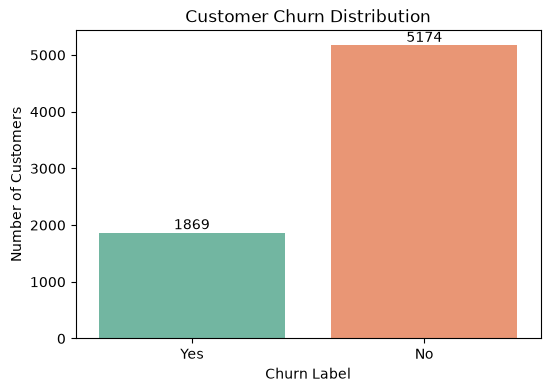

In [ ]:

# Customer Churn Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Churn Label",
    palette="Set2"
)

# Display count on each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")

plt.show()

Insight :
The dataset is imbalanced.
Around 5174 customers did not churn, while 1869 customers churned.
This means approximately 26.5% of customers left the company.
During model evaluation, Precision, Recall, and F1-score should be considered in addition to accuracy.

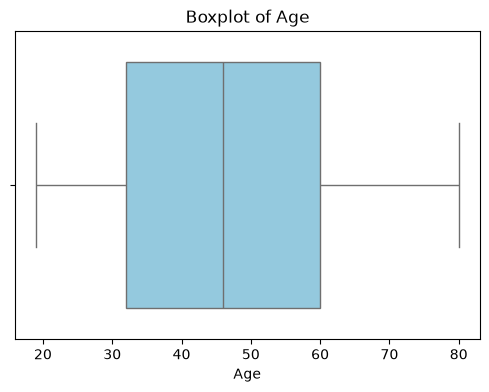

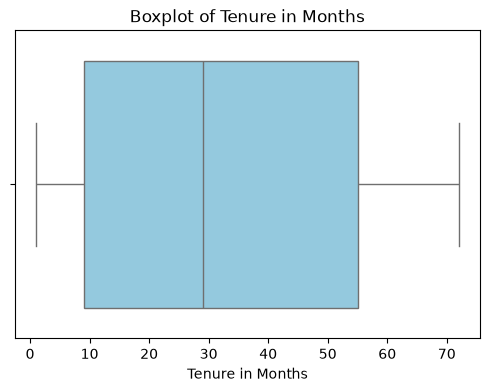

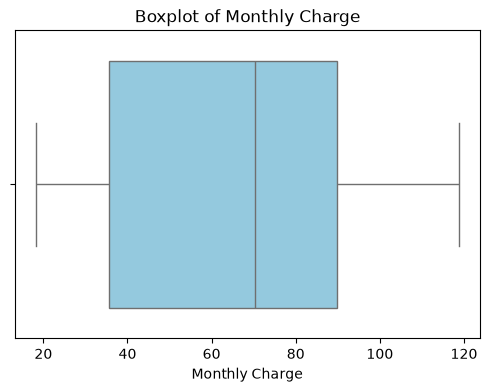

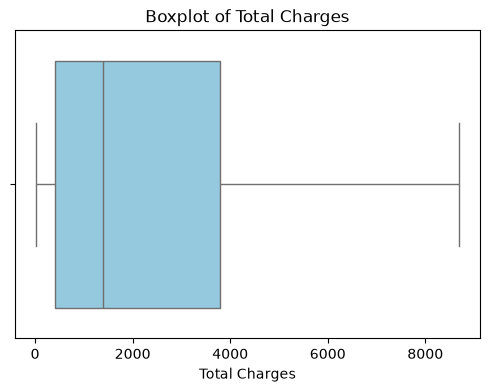

In [ ]:
#detect outliers using boxplot
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
numerical_columns = [
    "Age",
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges"
]

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [29]:
# Detect Outliers using IQR

numerical_columns = [
    "Age",
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges"
]

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"Number of Outliers: {len(outliers)}")


Column: Age
Number of Outliers: 0

Column: Tenure in Months
Number of Outliers: 0

Column: Monthly Charge
Number of Outliers: 0

Column: Total Charges
Number of Outliers: 0


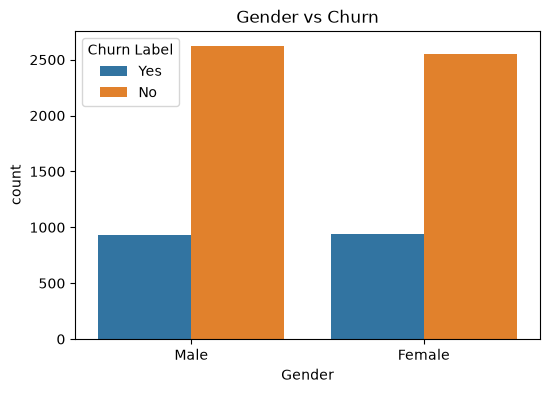

In [30]:
# churn vs gender
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Gender",
              hue="Churn Label")

plt.title("Gender vs Churn")
plt.show()

## insights:
Compare the bars for males and females.
If both genders have similar churn counts, gender is not a strong predictor.
If one gender has noticeably more churn, it may have some influence.

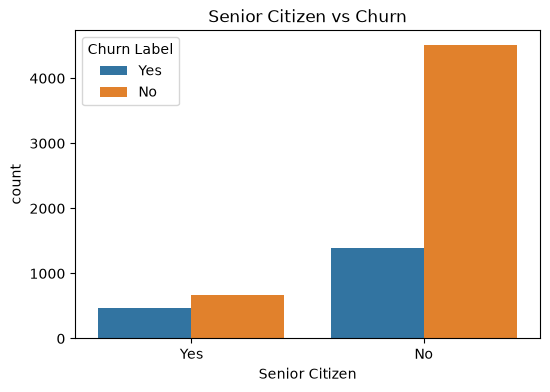

In [32]:
#citizen vs churn
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Senior Citizen",
              hue="Churn Label")

plt.title("Senior Citizen vs Churn")
plt.show()


### Insights:
Compare churn among senior and non-senior customers.
If senior citizens show a higher proportion of churn, age group may influence customer retention.


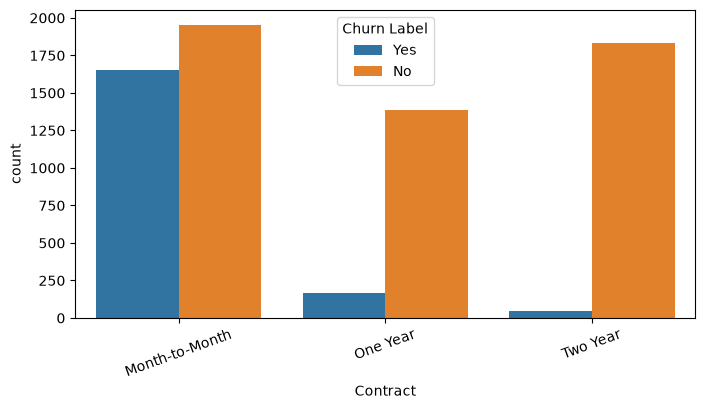

In [33]:
#Contract type vs churn
plt.figure(figsize=(8,4))

sns.countplot(data=df,
              x="Contract",
              hue="Churn Label")

plt.xticks(rotation=20)
plt.show()

## Insights
Customers with Month-to-Month contracts often have the highest churn.
Customers with One-Year and Two-Year contracts generally show lower churn.
Longer contracts are associated with better customer retention.

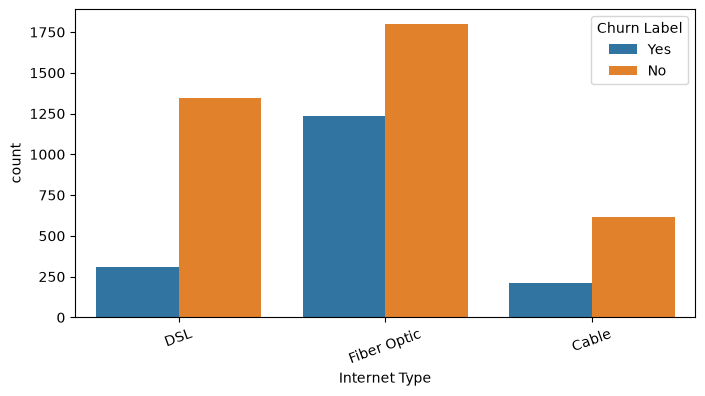

In [35]:
#Internet type vs churn
plt.figure(figsize=(8,4))

sns.countplot(data=df,
              x="Internet Type",
              hue="Churn Label")

plt.xticks(rotation=20)
plt.show()

## Insights
Compare churn across different internet service types.
If one service type has noticeably higher churn, it may indicate customer dissatisfaction or differences in customer profiles.

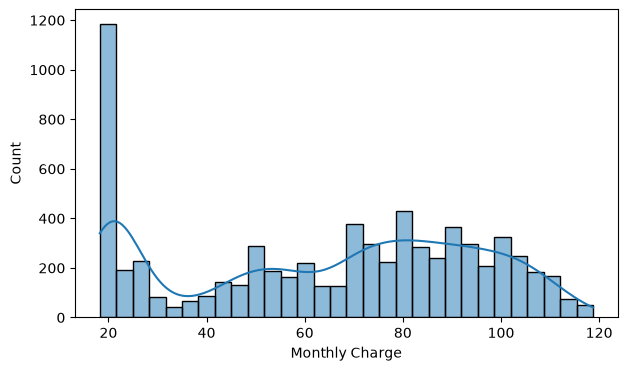

In [36]:
#Monthly charges distrubution
plt.figure(figsize=(7,4))

sns.histplot(df["Monthly Charge"],
             bins=30,
             kde=True)

plt.show()


## Insights
Observe where most customers' monthly charges fall.
If charges are concentrated in one range, that is the most common pricing level.
Very high monthly charges may be worth investigating for their relationship with churn.

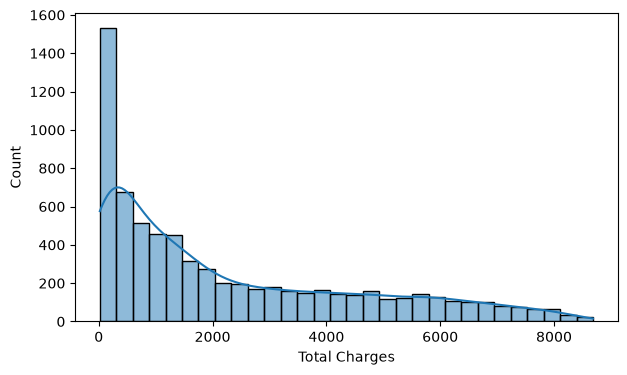

In [37]:
#Total charges distrubution
plt.figure(figsize=(7,4))

sns.histplot(df["Total Charges"],
             bins=30,
             kde=True)

plt.show()

## Insights
Total charges are often right-skewed because long-term customers accumulate larger bills.
Customers with higher total charges may simply have stayed with the company longer.

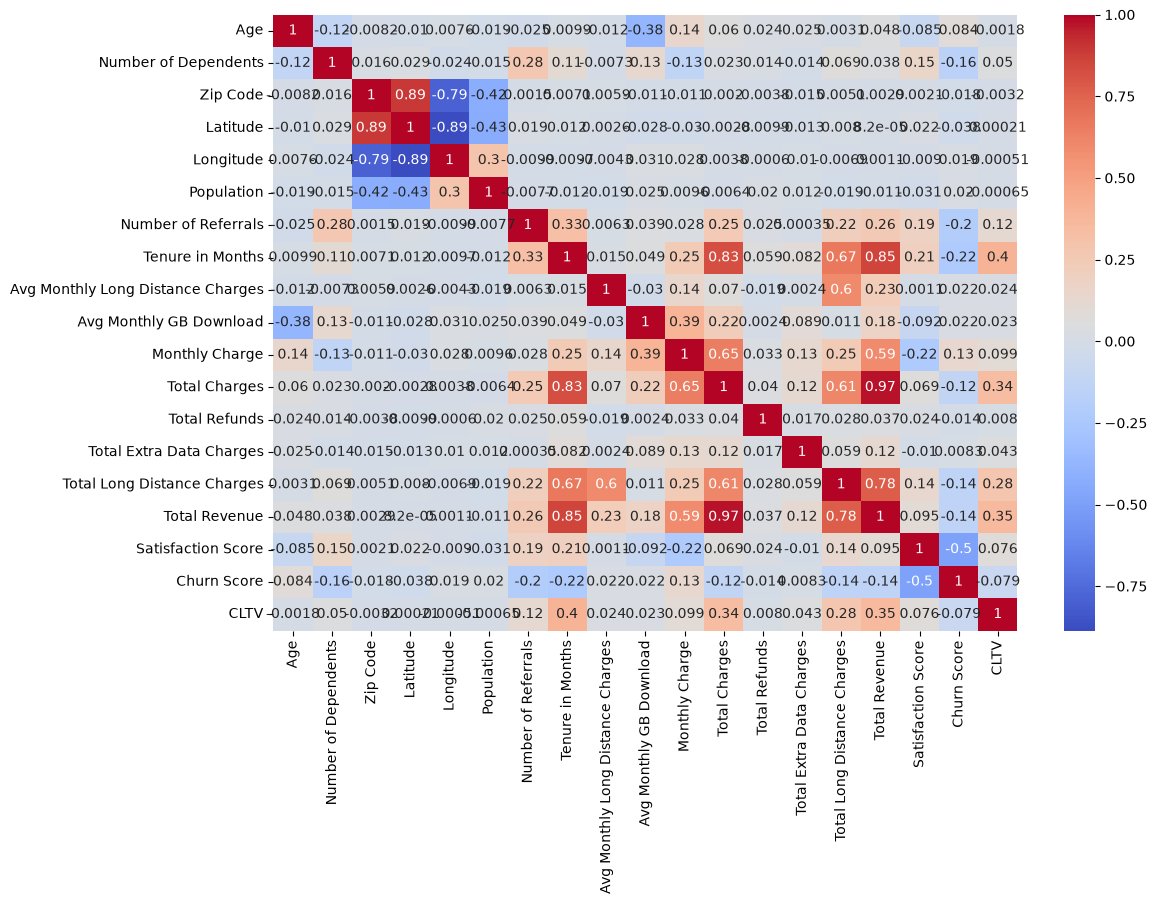

In [38]:
#correlation heat map
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()


## Insights
Features with stronger positive or negative correlations may be more useful for prediction.
Very highly correlated features can indicate redundancy and may need attention during feature selection.

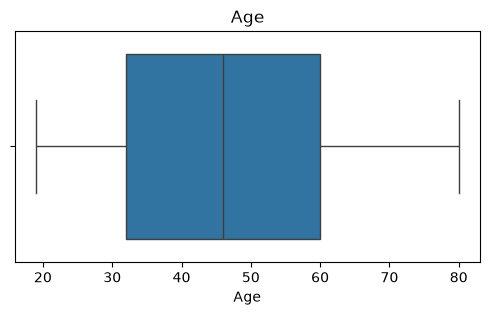

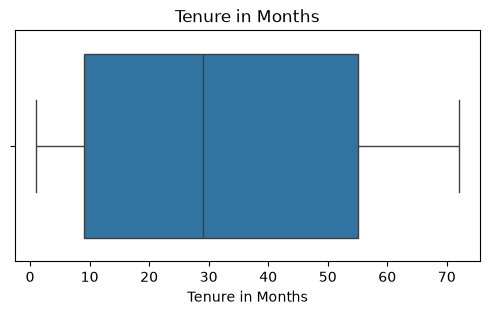

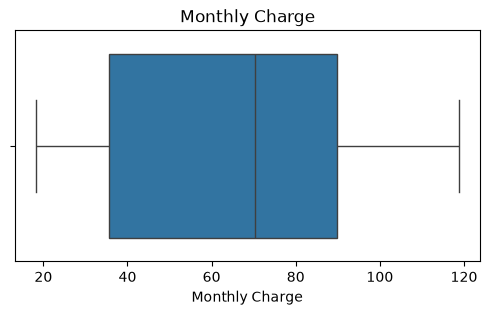

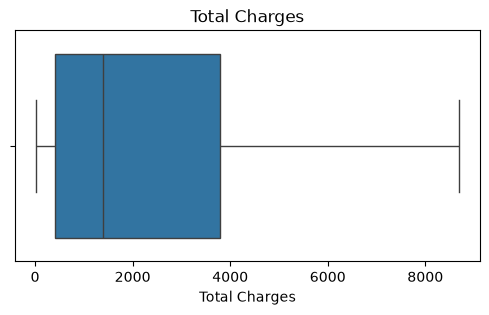

In [39]:
#Outlier Detection using Boxplot
columns = ["Age","Tenure in Months","Monthly Charge","Total Charges"]

for col in columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Insights

Outliers indicate unusually high or low values
Not all outliers should be removed; in customer data they may represent real, valuable cases (for example, customers with very long tenure or high bills).

In [42]:
# Data Preprocessing
#Encode categorical variables
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

encoder = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()

C:\Users\rishi\AppData\Local\Temp\ipykernel_12012\2751892905.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include="object").columns:


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,6207,1,78,0,1,0,0,0,0,0,...,20,0.00,59.65,3,0,1,91,5433,1,5
1,5305,0,74,0,1,1,1,1,0,0,...,0,390.80,1024.10,3,0,1,69,5302,1,3
2,1129,1,71,0,1,0,1,3,0,0,...,0,203.94,1910.88,2,0,1,81,3179,1,3
3,3208,0,78,0,1,1,1,1,0,0,...,0,494.00,2995.07,2,0,1,88,5337,2,11
4,3419,0,80,0,1,1,1,1,0,0,...,0,234.21,3102.36,2,0,1,67,2793,4,8


 ## Insight: 
 All categorical variables have been converted into numerical values using Label Encoding, making the dataset suitable for machine learning algorithms.

In [43]:
#Separate Features and Target
X = df_encoded.drop("Churn Label", axis=1)
y = df_encoded["Churn Label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (7043, 49)
Target Shape: (7043,)


## Insight:
 The dataset has been divided into input features (X) and the target variable (y) for training the prediction model.

In [44]:
#Split the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (5634, 49)
Testing Data: (1409, 49)


## Insight:
 The dataset has been split into 80% training data and 20% testing data. The training data is used to build the model, while the testing data is used to evaluate its performance.

In [46]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Insight: 
Numerical features have been standardized so that they have a similar scale. This helps algorithms such as Logistic Regression perform more effectively.

In [47]:
#Train the First Model (Logistic Regression)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Insight: 
A Logistic Regression model has been trained using the training dataset to predict whether a customer is likely to churn.

In [48]:
#Evaluate the Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
[[1009    0]
 [   0  400]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [49]:
print(X.columns.tolist())


['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']


In [50]:
# Remove columns that cause data leakage

columns_to_drop = [
    "Customer ID",
    "Customer Status",
    "Churn Score",
    "Churn Category",
    "Churn Reason"
]

df_model = df_encoded.drop(columns=columns_to_drop)

In [51]:
X = df_model.drop("Churn Label", axis=1)
y = df_model["Churn Label"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (7043, 44)
Target Shape: (7043,)


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9538679914833215

Confusion Matrix
[[985  24]
 [ 41 359]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1009
           1       0.94      0.90      0.92       400

    accuracy                           0.95      1409
   macro avg       0.95      0.94      0.94      1409
weighted avg       0.95      0.95      0.95      1409



## Insight:
The Logistic Regression model achieved an accuracy of 95.39%, indicating strong predictive performance. The model correctly classified 985 non-churn customers and 359 churn customers. With a precision of 94%, recall of 90%, and F1-score of 92% for the churn class, the model demonstrates a good balance between identifying churning customers and minimizing false predictions. These results suggest that Logistic Regression provides a reliable baseline model for customer churn prediction.

In [57]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report")
print(classification_report(y_test, dt_pred))

Accuracy: 0.9403832505322924

Confusion Matrix
[[974  35]
 [ 49 351]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1009
           1       0.91      0.88      0.89       400

    accuracy                           0.94      1409
   macro avg       0.93      0.92      0.93      1409
weighted avg       0.94      0.94      0.94      1409



In [58]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy: 0.9524485450674237

Confusion Matrix
[[1004    5]
 [  62  338]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1009
           1       0.99      0.84      0.91       400

    accuracy                           0.95      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409



In [86]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\rishi\Customer_Churn_Analysis\Data\telco.csv"
)

df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [92]:
drop_cols = [
    "Customer ID",
    "Churn Score",
    "Churn Category",
    "Churn Reason",
    "Customer Status"
]

df = df.drop(drop_cols, axis=1)

df.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label,CLTV
0,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,...,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Yes,5433
1,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,...,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Yes,5302
2,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,...,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Yes,3179
3,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,...,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Yes,5337
4,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,...,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Yes,2793


In [ ]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [2]:
import shap
import matplotlib.pyplot as plt

c:\Users\rishi\Customer_Churn_Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\rishi\Customer_Churn_Analysis\Data\telco.csv"
)

In [6]:
df = df.drop(
[
"Customer ID",
"Churn Score",
"Churn Category",
"Churn Reason",
"Customer Status"
],
axis=1
)

In [7]:
df["Customer_Value"] = (
    df["Monthly Charge"] *
    df["Tenure in Months"]
)

In [8]:
df["Churn Label"] = df["Churn Label"].map(
{
"No":0,
"Yes":1
}
)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

C:\Users\rishi\AppData\Local\Temp\ipykernel_5304\1688245245.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [10]:
from sklearn.model_selection import train_test_split


X = df.drop(
"Churn Label",
axis=1
)

y = df["Churn Label"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


rf.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [17]:
# Select churn = Yes class
shap_values_churn = shap_values[:, :, 1]

importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "Importance": abs(shap_values_churn).mean(axis=0)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
42,Satisfaction Score,0.189703
33,Contract,0.048596
16,Number of Referrals,0.024790
17,Tenure in Months,0.022799
36,Monthly Charge,0.020784
41,Total Revenue,0.014546
6,Number of Dependents,0.014435
25,Online Security,0.010891
24,Avg Monthly GB Download,0.010767
40,Total Long Distance Charges,0.010682


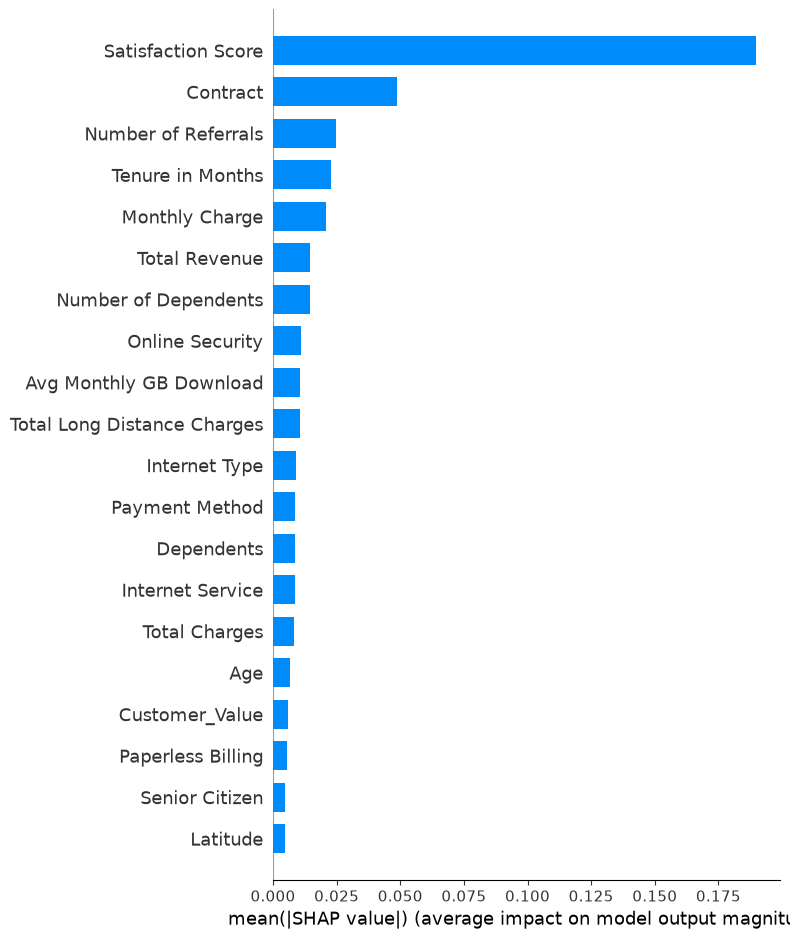

In [18]:
shap.summary_plot(
    shap_values_churn,
    X_test_sample,
    plot_type="bar"
)

## insight:
"SHAP analysis identifies that contract type, tenure, and monthly charges are the major factors influencing customer churn. Customers with shorter tenure, month-to-month contracts, and higher charges have a higher churn risk, helping the business target retention strategies effectively."

In [19]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\rishi\Customer_Churn_Analysis\Data\telco.csv"
)

df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [20]:
# create LTV feature
df["LTV"] = (
    df["Monthly Charge"] *
    df["Tenure in Months"]
)

df[["Monthly Charge","Tenure in Months","LTV"]].head()

,Monthly Charge,Tenure in Months,LTV
0,39.65,1,39.65
1,80.65,8,645.20
2,95.45,18,1718.10
3,98.50,25,2462.50
4,76.50,37,2830.50


In [21]:
#Removing unnecessary colums
df = df.drop(
[
"Customer ID",
"Churn Category",
"Churn Reason",
"Customer Status"
],
axis=1
)

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

C:\Users\rishi\AppData\Local\Temp\ipykernel_5304\1688245245.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [23]:
from sklearn.model_selection import train_test_split


X = df.drop("LTV", axis=1)

y = df["LTV"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestRegressor


ltv_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


ltv_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [25]:
ltv_pred = ltv_model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, r2_score


print(
"MAE:",
mean_absolute_error(y_test, ltv_pred)
)


print(
"R2 Score:",
r2_score(y_test, ltv_pred)
)

MAE: 43.555191980127724
R2 Score: 0.9992143964848786


## insights:
"The Random Forest Regression model successfully forecasts customer lifetime value with an R² score of 0.9992 and a low MAE of 43.55. This enables the business to estimate future customer revenue and identify high-value customers for retention strategies."

In [34]:
!pip install fastapi uvicorn nest_asyncio

In [35]:
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import nest_asyncio
import uvicorn
import pickle

In [36]:
app = FastAPI(title="Customer Lifetime Revenue Prediction API")

In [37]:
ltv_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [38]:
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import nest_asyncio
import uvicorn

app = FastAPI(title="Customer Lifetime Revenue Prediction API")

In [39]:
features = X.columns.tolist()

print(len(features))
print(features)

46
['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Churn Label', 'Churn Score', 'CLTV']


In [13]:
!pip install fastapi uvicorn nest_asyncio

In [14]:
from fastapi import FastAPI
import nest_asyncio
import uvicorn
import threading
import pandas as pd

app = FastAPI()

In [15]:
@app.post("/predict")
def predict(data: list):

    customer = pd.DataFrame(
        [data],
        columns=features
    )

    prediction = ltv_model.predict(customer)

    return {
        "predicted_revenue": float(prediction[0])
    }

In [11]:
@app.post("/batch_predict")
def batch_predict(data: list):

    customers = pd.DataFrame(
        data,
        columns=features
    )

    predictions = ltv_model.predict(customers)

    customers["predicted_revenue"] = predictions

    return customers.to_dict(orient="records")

NameError: name 'app' is not defined

In [10]:
nest_asyncio.apply()

def run():
    uvicorn.run(app, host="127.0.0.1", port=8000)

threading.Thread(target=run).start()

NameError: name 'nest_asyncio' is not defined

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Data/telco.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Data/telco.csv'

In [4]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "telco" in file.lower():
            print(os.path.join(root,file))

.\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [9]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'plt', 'sns', '_i2', 'pd', '_i3', '_i4', 'os', 'root', 'dirs', 'files', 'file', '_i5', '_i6', '_i7', '_i8', '_i9'])